# 03 — Biological & Anthropogenic Features

| Feature | Source | Resolution | Method |
|---|---|---|---|
| Canopy height | ETH Global Canopy Height (Lang et al. 2023) | 10 m → 30 m | Windowed COG read + bilinear regrid |
| NDVI annual max | GIMMS MODIS Terra MOD09Q1 (2020) | 250 m → 30 m | Growing-season max composite + nearest-neighbor regrid |
| Human Footprint Index | Mu et al. 2022 via Figshare (2009) | 1 km Mollweide → 30 m WGS84 | Reproject + nearest-neighbor regrid |
| Forest-edge distance | Derived from ESA Worldcover tree-cover fraction | 30 m (native) | `scipy.ndimage.distance_transform_edt` |

### ETH Global Canopy Height (10 m, 2020)

In [1]:
import config
from geo_utils import load_dem, compute_canopy_height
from s3_utils import save_zarr
from plot_utils import plot_raster

full_dem = load_dem()


Loading 24 tiles from S3...


In [5]:
canopy_height = compute_canopy_height(full_dem)

save_zarr(canopy_height, config.CANOPY_HEIGHT_ZARR,
          name="canopy_height")


Processing 6 canopy height tiles → 9010×17810 target grid
  Tile 1/6: ETH_GlobalCanopyHeight_10m_2020_N45E003_Map.tif
    Read window: 29169×3411 px
    Done.
  Tile 2/6: ETH_GlobalCanopyHeight_10m_2020_N45E006_Map.tif
    Read window: 29169×36000 px
    Done.
  Tile 3/6: ETH_GlobalCanopyHeight_10m_2020_N45E009_Map.tif
    Read window: 29169×19952 px
    Done.
  Tile 4/6: ETH_GlobalCanopyHeight_10m_2020_N48E003_Map.tif
    Read window: 859×3411 px
    Done.
  Tile 5/6: ETH_GlobalCanopyHeight_10m_2020_N48E006_Map.tif
    Read window: 859×36000 px
    Done.
  Tile 6/6: ETH_GlobalCanopyHeight_10m_2020_N48E009_Map.tif
    Read window: 859×19952 px
    Done.
  Canopy height: {'y': 9010, 'x': 17810}


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/canopy_height/canopy_height_30m.zarr


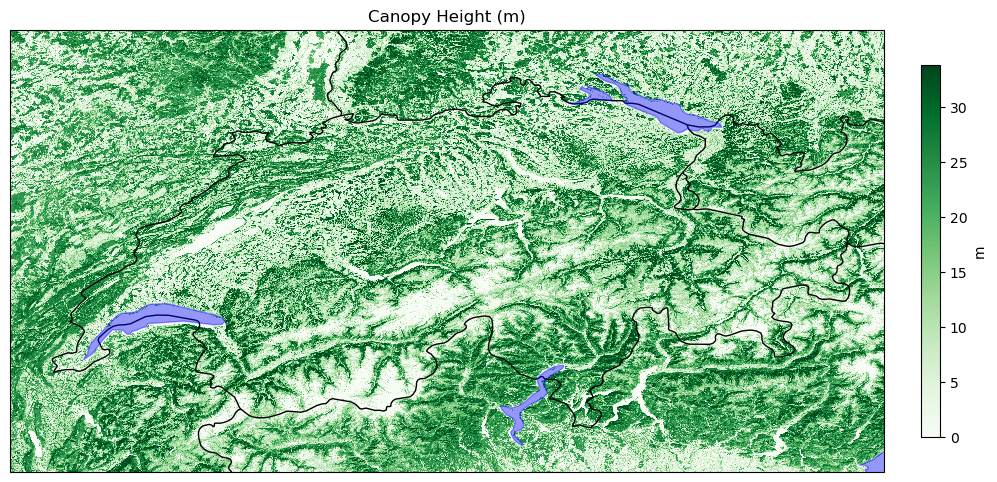

In [6]:
plot_raster(canopy_height, "Canopy Height (m)", cmap="Greens", label="m", robust=True)


### NDVI (annual growing-season maximum)

GIMMS MODIS Terra 250 m 8-day composites (DOY 97–273, Apr–Sep).
We take the per-pixel max across the growing season, then regrid to 30 m.

In [7]:
from geo_utils import compute_ndvi_annual_max

ndvi_max = compute_ndvi_annual_max(full_dem)

save_zarr(ndvi_max, config.NDVI_ZARR, name="ndvi_max")


Processing 23 GIMMS NDVI composites for 2020 (DOY 97–273)
  [1/23] DOY 97... ok
  [2/23] DOY 105... ok
  [3/23] DOY 113... ok
  [4/23] DOY 121... ok
  [5/23] DOY 129... ok
  [6/23] DOY 137... ok
  [7/23] DOY 145... ok
  [8/23] DOY 153... ok
  [9/23] DOY 161... ok
  [10/23] DOY 169... ok
  [11/23] DOY 177... ok
  [12/23] DOY 185... ok
  [13/23] DOY 193... ok
  [14/23] DOY 201... ok
  [15/23] DOY 209... ok
  [16/23] DOY 217... ok
  [17/23] DOY 225... ok
  [18/23] DOY 233... ok
  [19/23] DOY 241... ok
  [20/23] DOY 249... ok
  [21/23] DOY 257... ok
  [22/23] DOY 265... ok
  [23/23] DOY 273... ok
  Max composite shape: (1112, 2199), range: 0.000–1.000
  Regridding to 30 m master grid...
  NDVI annual max: {'y': 9010, 'x': 17810}


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/ndvi/ndvi_max_30m.zarr


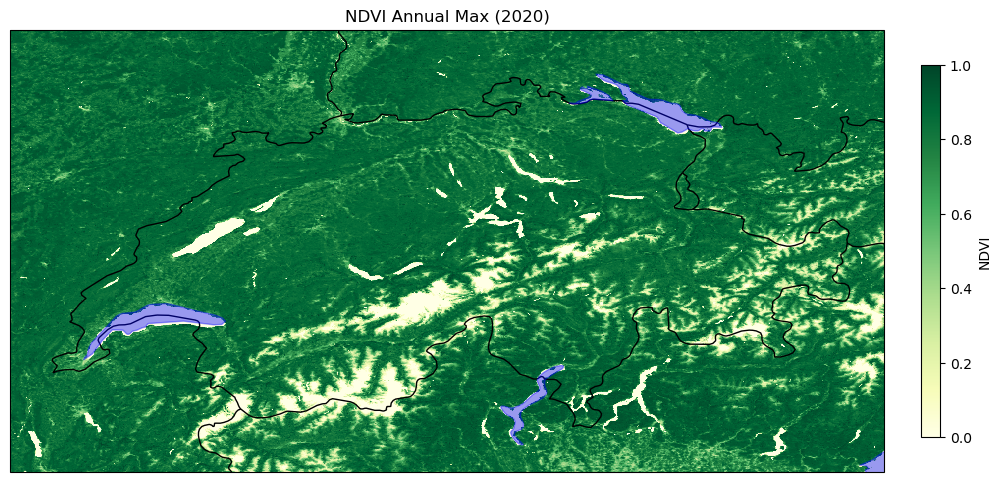

In [8]:
plot_raster(ndvi_max, "NDVI Annual Max (2020)", cmap="YlGn", label="NDVI", vmin=0, vmax=1)


### Human Footprint Index (Mu et al. 2022)

Global 1 km annual HFP from Figshare (year 2009, most recent available).
Mollweide projection → reprojected and regridded to 30 m WGS84.

In [2]:
from geo_utils import compute_human_footprint

hfp = compute_human_footprint(full_dem)

save_zarr(hfp, config.HFP_ZARR,
          name="human_footprint")


  Extracting...
  Reading hfp2009.tif...
  Source shape: (16382, 36081), CRS: ESRI:54009
  Reprojecting to 30 m master grid...
  Human Footprint: {'y': 9010, 'x': 17810}, range: 0.4–50.0


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/hfp/human_footprint_30m.zarr


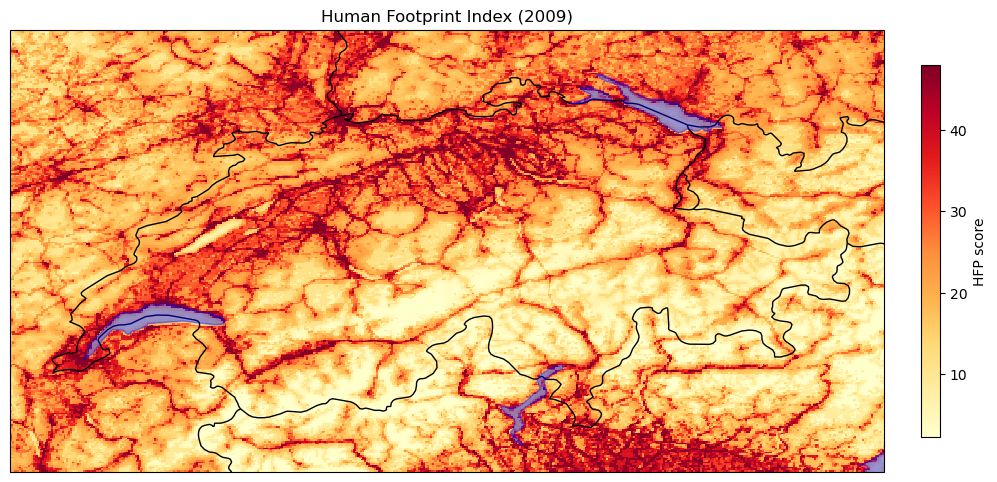

In [3]:
plot_raster(hfp, "Human Footprint Index (2009)", cmap="YlOrRd", label="HFP score", robust=True)


### Forest-edge distance

Derived from the tree-cover fraction layer (computed in notebook 01).

In [4]:
from s3_utils import load_zarr
from geo_utils import compute_forest_edge_distance

lc_fractions = load_zarr(
    config.LC_FRACTIONS_ZARR,
    name="lc_fraction",
)

forest_edge_dist = compute_forest_edge_distance(lc_fractions)

save_zarr(forest_edge_dist,
          config.FOREST_EDGE_ZARR,
          name="forest_edge_distance")


/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=22, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/sagemaker-user/.conda/envs/cas/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Saved → s3://km-cas-datalake/processed/forest_edge/forest_edge_distance_30m.zarr


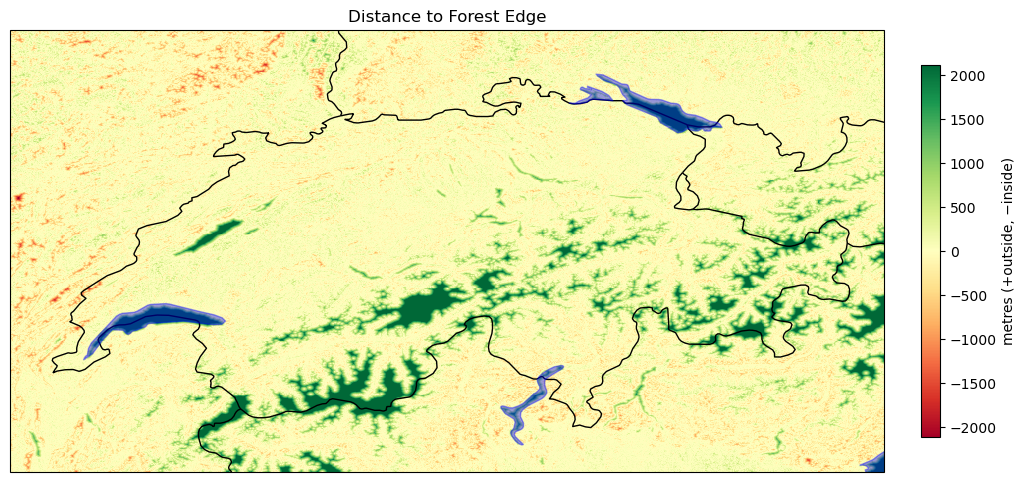

In [5]:
plot_raster(forest_edge_dist, "Distance to Forest Edge",
            cmap="RdYlGn", robust=True, label="metres (+outside, −inside)")
